# E3: Mapping with Cartopy

**Author:** Asanda Sharlene Mthembu (MTHASA034)

Two maps made with Cartopy: one of Antarctica and the Southern Ocean, and one of the South Atlantic with four port cities marked.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import warnings
warnings.filterwarnings('ignore')

In [2]:
# colours and font sizes shared by both maps
OCEAN_COLOR   = '#cce5f0'
LAND_COLOR    = '#e8dcc8'
ICE_COLOR     = '#f0f4f8'
COAST_COLOR   = '#4a4a4a'
GRID_COLOR    = '#888888'
CITY_COLOR    = '#c0392b'
HALO          = 'white'

TITLE_SIZE = 13
LABEL_SIZE = 10
TICK_SIZE  = 9

## Map 1: Antarctica and the Southern Ocean

I used the South Polar Stereographic projection because it shows the region around the pole as a circle with little distortion. A Mercator map stretches the high latitudes too much to be useful here. The extent is given in lon/lat (PlateCarree) and Cartopy converts it to the polar projection.

The built-in `draw_labels` option for gridlines does not work well in polar projections, so the latitude and longitude labels are added by hand with `ax.text`.

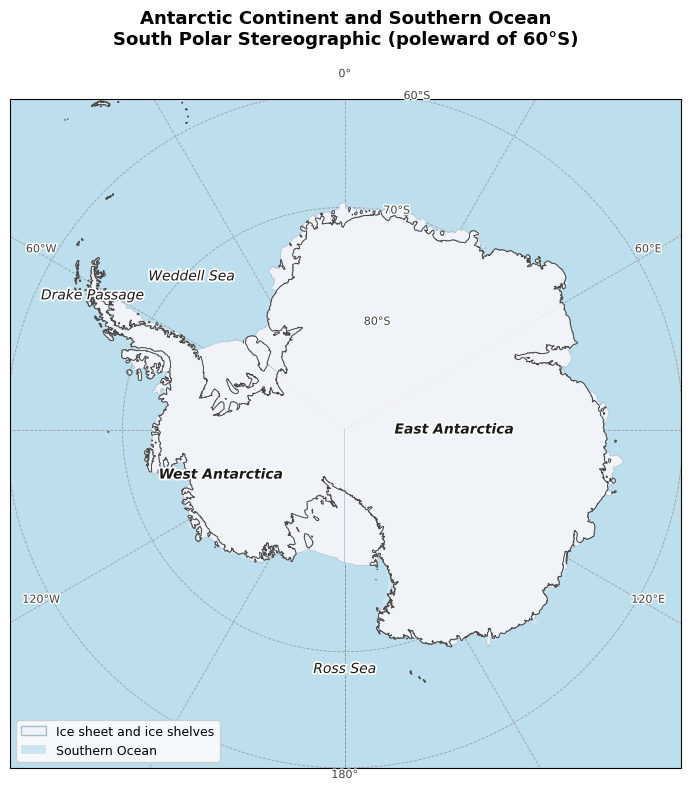

In [3]:
fig1, ax1 = plt.subplots(
    figsize=(8, 8),
    subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=0)}
)

ax1.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
ax1.set_facecolor(OCEAN_COLOR)

# 10m resolution is used because the Antarctic coastline is very detailed
land_10m = cfeature.NaturalEarthFeature(
    'physical', 'land', '10m',
    facecolor=LAND_COLOR, edgecolor=COAST_COLOR, linewidth=0.6
)
ice_10m = cfeature.NaturalEarthFeature(
    'physical', 'antarctic_ice_shelves_polys', '10m',
    facecolor=ICE_COLOR, edgecolor='#aabbcc', linewidth=0.4
)
glaciers = cfeature.NaturalEarthFeature(
    'physical', 'glaciated_areas', '10m',
    facecolor=ICE_COLOR, edgecolor='none'
)

# lighter ocean layer underneath
ax1.add_feature(
    cfeature.NaturalEarthFeature('physical', 'ocean', '110m',
                                 facecolor='#a8d5e8', edgecolor='none'),
    zorder=1, alpha=0.4
)
ax1.add_feature(land_10m, zorder=2)
ax1.add_feature(glaciers, zorder=3)
ax1.add_feature(ice_10m,  zorder=4)
ax1.add_feature(cfeature.COASTLINE.with_scale('10m'),
                edgecolor=COAST_COLOR, linewidth=0.7, zorder=5)

# gridlines (labels are added by hand below)
gl1 = ax1.gridlines(
    crs=ccrs.PlateCarree(),
    linewidth=0.6, color=GRID_COLOR, alpha=0.7, linestyle='--', zorder=6
)
gl1.xlocator = mticker.FixedLocator(range(-180, 181, 30))
gl1.ylocator = mticker.FixedLocator([-90, -80, -70, -60])

# latitude labels, placed just to the right of the 0 degree meridian
for lat, lab in [(-60, '60°S'), (-70, '70°S'), (-80, '80°S')]:
    ax1.text(
        10, lat, lab,
        transform=ccrs.PlateCarree(),
        fontsize=TICK_SIZE - 1, color='#444444',
        ha='left', va='center',
        path_effects=[pe.withStroke(linewidth=2, foreground=HALO)],
        zorder=7
    )

# longitude labels around the edge of the map
for lon, lab in zip(
    [-180, -120, -60, 0, 60, 120],
    ['180°', '120°W', '60°W', '0°', '60°E', '120°E']
):
    ax1.text(
        lon, -59, lab,
        transform=ccrs.PlateCarree(),
        fontsize=TICK_SIZE - 1, color='#444444',
        ha='center', va='bottom',
        path_effects=[pe.withStroke(linewidth=2, foreground=HALO)],
        zorder=7
    )

# place names (bold for land, plain italic for seas)
geo_labels = [
    (-45, -70.5, 'Weddell Sea',     False),
    (180, -68.5, 'Ross Sea',        False),
    ( 90, -80,   'East Antarctica', True),
    (-110,-78,   'West Antarctica', True),
    (-62, -64.5, 'Drake Passage',   False),
]
for lon, lat, name, bold in geo_labels:
    ax1.text(
        lon, lat, name,
        transform=ccrs.PlateCarree(),
        fontsize=LABEL_SIZE,
        fontweight='bold' if bold else 'normal',
        style='italic',
        color='#1a1a1a', ha='center', va='center',
        path_effects=[pe.withStroke(linewidth=2.5, foreground=HALO)],
        zorder=8
    )

# South Pole crosshair
ax1.plot(0, -90, marker='+', markersize=10, markeredgewidth=1.5,
         color='#333333', transform=ccrs.PlateCarree(), zorder=9)

ax1.set_title(
    'Antarctic Continent and Southern Ocean\nSouth Polar Stereographic (poleward of 60°S)',
    fontsize=TITLE_SIZE, fontweight='bold', pad=40
)

ax1.legend(
    handles=[
        mpatches.Patch(facecolor=ICE_COLOR,   edgecolor='#aabbcc',   label='Ice sheet and ice shelves'),
        mpatches.Patch(facecolor=OCEAN_COLOR, edgecolor='none',       label='Southern Ocean'),
    ],
    loc='lower left', fontsize=TICK_SIZE, framealpha=0.85, edgecolor='#cccccc'
)

plt.tight_layout()
plt.savefig('map1_antarctica_southern_ocean.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## Map 2: South Atlantic (20°S to 50°S)

This map uses the Plate Carrée projection. At these latitudes the distortion is small and the plain lon/lat grid makes it easy to read off the position of each port. The extent runs from 62°W to 25°E so that both South America and southern Africa are in the map. Each city label has its own offset so it does not sit on top of the coastline.

In [4]:
cities = {
    'Walvis Bay':     ( 14.505, -22.959),
    'Cape Town':      ( 18.424, -33.925),
    'Rio de Janeiro': (-43.173, -22.907),
    'Montevideo':     (-56.165, -34.901),
}

# label offsets (degrees) and alignment, chosen so labels sit in the ocean
city_offsets = {
    'Walvis Bay':     (-1.0,  0.8, 'right'),
    'Cape Town':      (-1.0, -1.2, 'right'),
    'Rio de Janeiro': ( 1.0,  0.8, 'left'),
    'Montevideo':     ( 1.0, -1.2, 'left'),
}

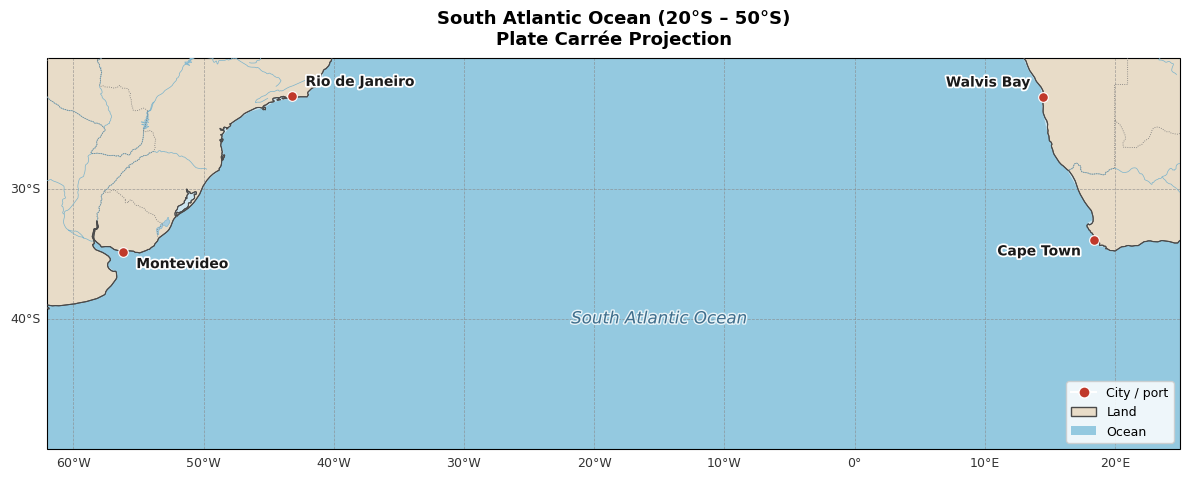

In [5]:
fig2, ax2 = plt.subplots(
    figsize=(12, 7),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

ax2.set_extent([-62, 25, -50, -20], crs=ccrs.PlateCarree())
ax2.set_facecolor(OCEAN_COLOR)

# ocean base layer
ax2.add_feature(
    cfeature.NaturalEarthFeature('physical', 'ocean', '110m',
                                 facecolor='#94c9e0', edgecolor='none'),
    zorder=1
)

ax2.add_feature(
    cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                 facecolor=LAND_COLOR, edgecolor=COAST_COLOR,
                                 linewidth=0.7),
    zorder=2
)
ax2.add_feature(
    cfeature.NaturalEarthFeature('physical', 'lakes', '50m',
                                 facecolor='#aaccdd', edgecolor='#7ab3cc',
                                 linewidth=0.4),
    zorder=3
)
# rivers
ax2.add_feature(
    cfeature.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '50m',
                                 facecolor='none', edgecolor='#7ab3cc',
                                 linewidth=0.5),
    zorder=3
)
ax2.add_feature(cfeature.BORDERS.with_scale('50m'),
                edgecolor='#777777', linewidth=0.6, linestyle=':', zorder=4)
ax2.add_feature(cfeature.COASTLINE.with_scale('50m'),
                edgecolor=COAST_COLOR, linewidth=0.8, zorder=5)

gl2 = ax2.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.55, color=GRID_COLOR, alpha=0.7, linestyle='--', zorder=6
)
gl2.top_labels   = False
gl2.right_labels = False
gl2.xformatter   = LONGITUDE_FORMATTER
gl2.yformatter   = LATITUDE_FORMATTER
gl2.xlabel_style = {'size': TICK_SIZE, 'color': '#333333'}
gl2.ylabel_style = {'size': TICK_SIZE, 'color': '#333333'}
gl2.xlocator = mticker.FixedLocator(range(-60, 26, 10))
gl2.ylocator = mticker.FixedLocator(range(-50, -19, 10))

for city, (lon, lat) in cities.items():
    ax2.plot(lon, lat,
             marker='o', markersize=7, color=CITY_COLOR,
             markeredgecolor='white', markeredgewidth=0.8,
             transform=ccrs.PlateCarree(), zorder=9)
    dlon, dlat, ha = city_offsets[city]
    ax2.text(
        lon + dlon, lat + dlat, city, ha=ha,
        transform=ccrs.PlateCarree(),
        fontsize=LABEL_SIZE, fontweight='bold', color='#1a1a1a',
        path_effects=[pe.withStroke(linewidth=2.5, foreground=HALO)],
        zorder=10
    )

ax2.text(
    -15, -40, 'South Atlantic Ocean',
    transform=ccrs.PlateCarree(),
    fontsize=12, style='italic', color='#1a5276',
    ha='center', va='center', alpha=0.8,
    path_effects=[pe.withStroke(linewidth=2, foreground='white')],
    zorder=7
)

ax2.set_title(
    'South Atlantic Ocean (20°S – 50°S)\nPlate Carrée Projection',
    fontsize=TITLE_SIZE, fontweight='bold', pad=10
)

ax2.legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=CITY_COLOR, markeredgecolor='white',
                   markersize=8, label='City / port'),
        mpatches.Patch(facecolor=LAND_COLOR, edgecolor=COAST_COLOR, label='Land'),
        mpatches.Patch(facecolor='#94c9e0',  edgecolor='none',      label='Ocean'),
    ],
    loc='lower right', fontsize=TICK_SIZE, framealpha=0.85, edgecolor='#cccccc'
)

plt.tight_layout()
plt.savefig('map2_south_atlantic.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()